# Combining Markov Degradation Models and Data-Driven Diagnostics for Hidden-State Inference in Condition-Based Maintenance

This notebook is organized the same as the study. It starts with the case-study inputs, then the transition matrix estimate, next is the held-out state-estimation evaluation, and lastly the maintenance cost comparison. 


## Computational Setup

The following cell imports the local reproducibility modules and sets display defaults.


In [2]:
from pathlib import Path
import shutil
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from main import appendix_c as ac
from main import case_study as cs
from main import maintenance_cost as mc
from main import parameter_tuning as pt
from main import state_estimation as se
from main import transition_estimation as te

ac = importlib.reload(ac)
cs = importlib.reload(cs)
mc = importlib.reload(mc)
pt = importlib.reload(pt)
se = importlib.reload(se)
te = importlib.reload(te)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

display(Markdown(f"Project root: `{PROJECT_ROOT}`"))

Project root: `C:\Users\20202809\1MIAC15\0. Complete\paper_reproducible_results`

## Section 4. Case Study and Evaluation Inputs

This section records the severity-expanded state space, diagnostic observation model, data-generating transition matrix, and bearing-level split used for parameter selection and held-out evaluation.


In [3]:
DATASET4 = PROJECT_ROOT / "data" / "raw" / "transition_estimation" / "bearing_reliability_4_censored_mode_augmented.csv"
RUNS_INPUT = PROJECT_ROOT / "data" / "generated" / "bearing_runs_to_failure.csv"
CONFUSION_MATRIX = PROJECT_ROOT / "data" / "raw" / "diagnostics" / "Confusion_Matrix.csv"
PAPER_TRANSITION_MATRIX = PROJECT_ROOT / "data" / "transition_matrices" / "right_censored_endpoint.csv"
DATASET4_OBSERVATION_FIGURE_SOURCE = PROJECT_ROOT.parents[1] / "1MIAC15___journal_version" / "Figures" / "fig_dataset4_observation_views.png"

TABLE_DIR = PROJECT_ROOT / "results" / "tables"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"
for directory in (TABLE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)
DATASET4_OBSERVATION_FIGURE = FIGURE_DIR / "fig_dataset4_observation_views.png"
if DATASET4_OBSERVATION_FIGURE_SOURCE.exists():
    shutil.copy2(DATASET4_OBSERVATION_FIGURE_SOURCE, DATASET4_OBSERVATION_FIGURE)

MAX_ITER = 2000
TOL = 2e-6
PAPER_REPORTED_ITERATIONS = 908
PREDICTION_SEED = 42
TRAIN_FRACTION = 0.7
ALPHA_MIN = 0.0
ALPHA_MAX = 2.0
ALPHA_STEP = 0.2
BETA_MIN = 0.0
BETA_MAX = 2.0
BETA_STEP = 0.2
EPSILON_G = 1e-4
BASELINE_ALPHA = 1.0
BASELINE_BETA = 1.0
BASELINE_EPSILON_G = 0.0
COSTS = mc.CostParameters(preventive=10.0, corrective=50.0)

settings = pd.DataFrame([
    {"setting": "max_em_iterations", "value": MAX_ITER},
    {"setting": "em_convergence_tolerance", "value": TOL},
    {"setting": "diagnostic_sampling_seed", "value": PREDICTION_SEED},
    {"setting": "training_fraction", "value": TRAIN_FRACTION},
    {"setting": "alpha_min", "value": ALPHA_MIN},
    {"setting": "alpha_max", "value": ALPHA_MAX},
    {"setting": "alpha_step", "value": ALPHA_STEP},
    {"setting": "beta_min", "value": BETA_MIN},
    {"setting": "beta_max", "value": BETA_MAX},
    {"setting": "beta_step", "value": BETA_STEP},
    {"setting": "epsilon_G", "value": EPSILON_G},
    {"setting": "baseline_alpha", "value": BASELINE_ALPHA},
    {"setting": "baseline_beta", "value": BASELINE_BETA},
    {"setting": "baseline_epsilon_G", "value": BASELINE_EPSILON_G},
    {"setting": "C_P", "value": COSTS.preventive},
    {"setting": "C_C", "value": COSTS.corrective},
])
display(settings)

,setting,value
0,max_em_iterations,2000.000000
1,em_convergence_tolerance,0.000002
2,diagnostic_sampling_seed,42.000000
3,training_fraction,0.700000
4,alpha_min,0.000000
5,alpha_max,2.000000
6,alpha_step,0.200000
7,beta_min,0.000000
8,beta_max,2.000000
9,beta_step,0.200000


These settings define the EM convergence tolerance and iteration limit, the 70/30 trajectory split, the candidate grids for `alpha` and `beta`, the likelihood floor `epsilon_G=1e-4`, and the replacement costs `C_P=10` and `C_C=50`. The unweighted Bayes baseline is evaluated with `alpha=1`, `beta=1`, and `epsilon_G=0`, because the likelihood floor is a numerical/design addition rather than part of the theoretical Bayes-rule baseline. The local cost helper also contains an inspection-cost field, but it is not a paper parameter for the CBR0/CBR1 threshold policies because no inspections are scheduled.


### 4.1 Bearing state space and severity labelling

The following cell records the physical severity mapping and the structural transition matrix used by the paper. The generated tables are cached and reused when the input data files and train/test split are unchanged.


In [4]:
case_study = cs.build_case_study(
    dataset4_path=DATASET4,
    runs_input_path=RUNS_INPUT,
    output_dir=TABLE_DIR,
    train_fraction=TRAIN_FRACTION,
)

case_study_cache_status = "loaded from cache" if case_study.cache_hit else "computed and cached"
display(Markdown(f"Case-study tables were `{case_study_cache_status}`."))
display(Markdown("### State space"))
display(case_study.state_space)

display(Markdown("### Severity-threshold mapping"))
display(case_study.severity_thresholds)

display(Markdown("### Structural transition matrix"))
display(case_study.structural_transition_matrix)


Case-study tables were `loaded from cache`.

### State space

,state,fault_mode,severity,interpretation
0,H,none,0,healthy
1,O1,outer race,1,mild outer-race degradation
2,O2,outer race,2,advanced outer-race degradation
3,I1,inner race,1,mild inner-race degradation
4,I2,inner race,2,advanced inner-race degradation
5,B1,ball defect,1,mild ball-defect degradation
6,B2,ball defect,2,advanced ball-defect degradation
7,F,failed,3,absorbing failure state


### Severity-threshold mapping

,fault_mode,state,severity_level,severity_label,fault_length_interval_mm,physical_stage
0,outer race,O1,1,mild / pre-accelerated,0 <= Delta l < 0.5,initial plus slow evolution
1,outer race,O2,2,advanced / accelerated,0.5 <= Delta l <= 0.8,accelerated evolution
2,inner race,I1,1,mild / pre-accelerated,0 <= Delta l < 0.5,initial plus slow evolution
3,inner race,I2,2,advanced / accelerated,0.5 <= Delta l <= 0.8,accelerated evolution
4,ball defect,B1,1,mild / pre-accelerated,0 <= Delta l < 0.5,initial plus slow evolution
5,ball defect,B2,2,advanced / accelerated,0.5 <= Delta l <= 0.8,accelerated evolution


### Structural transition matrix

,H,O1,O2,I1,I2,B1,B2,F
from_state,,,,,,,,
H,"p_H,H","p_H,O1",0,"p_H,I1",0,"p_H,B1",0,0
O1,0,"p_O1,O1","p_O1,O2",0,0,0,0,0
O2,0,0,"p_O2,O2",0,0,0,0,"p_O2,F"
I1,0,0,0,"p_I1,I1","p_I1,I2",0,0,0
I2,0,0,0,0,"p_I2,I2",0,0,"p_I2,F"
B1,0,0,0,0,0,"p_B1,B1","p_B1,B2",0
B2,0,0,0,0,0,0,"p_B2,B2","p_B2,F"
F,0,0,0,0,0,0,0,1


The physical severity rule maps initial and slow fault evolution to severity level 1 (`0 <= Delta l < 0.5 mm`) and accelerated evolution to severity level 2 (`0.5 <= Delta l <= 0.8 mm`). The structural transition matrix enforces monotone degradation: bearings can remain in their current state or progress along one selected fault branch, but cannot recover or switch fault modes.


### 4.2 Diagnostic model for the case study

The diagnostic observation model is the empirical CNN confusion matrix used to sample and correct diagnostic labels in the evaluation.


In [5]:
diagnostic_observation_model = pd.read_csv(CONFUSION_MATRIX).set_index("true_state")
display(diagnostic_observation_model)


,H,O1,O2,I1,I2,B1,B2
true_state,,,,,,,
H,15,0,0,0,0,0,0
O1,12,3,0,0,0,0,0
O2,11,4,0,0,0,0,0
I1,0,0,0,14,1,0,0
I2,0,0,0,0,15,0,0
B1,0,0,0,0,0,15,0
B2,0,0,0,0,0,1,14


The matrix contains 15 held-out diagnostic test samples per true operating state. Healthy, `I2`, and `B1` are perfectly recalled in this diagnostic test set, whereas `O1` and `O2` are mostly assigned to `H`. This class dependence explains why temporal information is expected to help most in the outer-race branch.


### 4.3 Evaluation design and state-fusion exponent tuning

The next cell reports the benchmark data-generating transition matrix `P0`; the bearing-level split used for tuning and held-out evaluation is stated below in words.


In [6]:
display(Markdown("### Data-generating transition matrix P0"))
display(case_study.data_generating_transition_matrix.style.format("{:.3f}"))


### Data-generating transition matrix P0

,H,O1,O2,I1,I2,B1,B2,F
state,,,,,,,,
H,0.890,0.060,0.000,0.030,0.000,0.020,0.000,0.000
O1,0.000,0.900,0.100,0.000,0.000,0.000,0.000,0.000
O2,0.000,0.000,0.890,0.000,0.000,0.000,0.000,0.110
I1,0.000,0.000,0.000,0.800,0.200,0.000,0.000,0.000
I2,0.000,0.000,0.000,0.000,0.810,0.000,0.000,0.190
B1,0.000,0.000,0.000,0.000,0.000,0.640,0.360,0.000
B2,0.000,0.000,0.000,0.000,0.000,0.000,0.550,0.450
F,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000


The benchmark matrix `P0` is the fully observed/transition-time transition matrix used by the parent simulation generator. It is distinct from the right-censored endpoint matrix estimated later and used as the temporal model in the posterior filter.

The right-censored transition-estimation sample contains 100 trajectories: 50 failed bearings and 50 right-censored endpoint observations at `t=20`. The generated run-to-failure sample contains 1000 separate trajectories. The first 700 trajectories are used for grid-search tuning of `alpha`, `beta`, and the maintenance thresholds, and the remaining 300 trajectories are held out for the reported state-estimation and maintenance results. The transition-estimation sample and generated evaluation sample are stored in separate files and are treated as disjoint trajectory samples.

The following cell reproduces the training-split grid search for the state-fusion exponents described in Appendix B.2. The grid-search output is cached and reused when the input files, grid definition, seed, split, and likelihood floor match the stored metadata.


In [7]:
tuning_result = pt.cached_alpha_beta_grid_search(
    runs_input_path=RUNS_INPUT,
    confusion_matrix_path=CONFUSION_MATRIX,
    transition_matrix_path=PAPER_TRANSITION_MATRIX,
    output_dir=TABLE_DIR,
    seed=PREDICTION_SEED,
    train_fraction=TRAIN_FRACTION,
    alpha_min=ALPHA_MIN,
    alpha_max=ALPHA_MAX,
    alpha_step=ALPHA_STEP,
    beta_min=BETA_MIN,
    beta_max=BETA_MAX,
    beta_step=BETA_STEP,
    epsilon_g=EPSILON_G,
)

selected_alpha_beta = tuning_result.selected.iloc[0]
ALPHA = float(selected_alpha_beta["alpha"])
BETA = float(selected_alpha_beta["beta"])
cache_status = "loaded from cache" if tuning_result.cache_hit else "computed and cached"

display(Markdown(
    f"Grid-search results were `{cache_status}`. Selected `alpha={ALPHA:g}` and `beta={BETA:g}` "
    f"with training accuracy `{selected_alpha_beta['training_accuracy']:.4f}`."
))
display(tuning_result.selected.style.format({
    "alpha": "{:.1f}",
    "beta": "{:.1f}",
    "training_accuracy": "{:.4f}",
}))


Grid-search results were `loaded from cache`. Selected `alpha=1` and `beta=1.8` with training accuracy `0.7736`.

,alpha,beta,training_bearings,training_operating_observations,training_accuracy
0,1.0,1.8,700,16629,0.7736


The selected exponents are then fixed before held-out state-estimation and maintenance evaluation. This reproduces the paper's separation between training-split parameter selection and held-out testing.


## 5 Results


### 5.1 Transition-matrix estimation

The following cell summarizes the right-censored transition-estimation data used by the EM estimator.


,quantity,value
0,bearings,100
1,failed,50
2,censored,50
3,censoring_time,20


### Failed bearings by fault mode and time

count
fault_mode  observed_time       
Ball defect 4                2.0
            6                1.0
            7                1.0
            10               1.0
            11               1.0
            12               3.0
            13               1.0
            14               1.0
            15               1.0
            16               1.0
            17               1.0
            18               1.0
Inner race  5                2.0
            7                3.0
            8                1.0
            10               3.0
            13               3.0
            14               4.0
            16               2.0
            18               2.0
Outer race  7                1.0
            8                1.0
            9                1.0
            10               1.0
            11               6.0
            12               1.0
            16               1.0
            18               2.0
            20               1.0

### Censored bearings by endpoint state and time

,,count
observed_state,observed_time,
B2,20,2.0
H,20,11.0
I1,20,2.0
I2,20,5.0
O1,20,12.0
O2,20,18.0


### Dataset 4 observation view

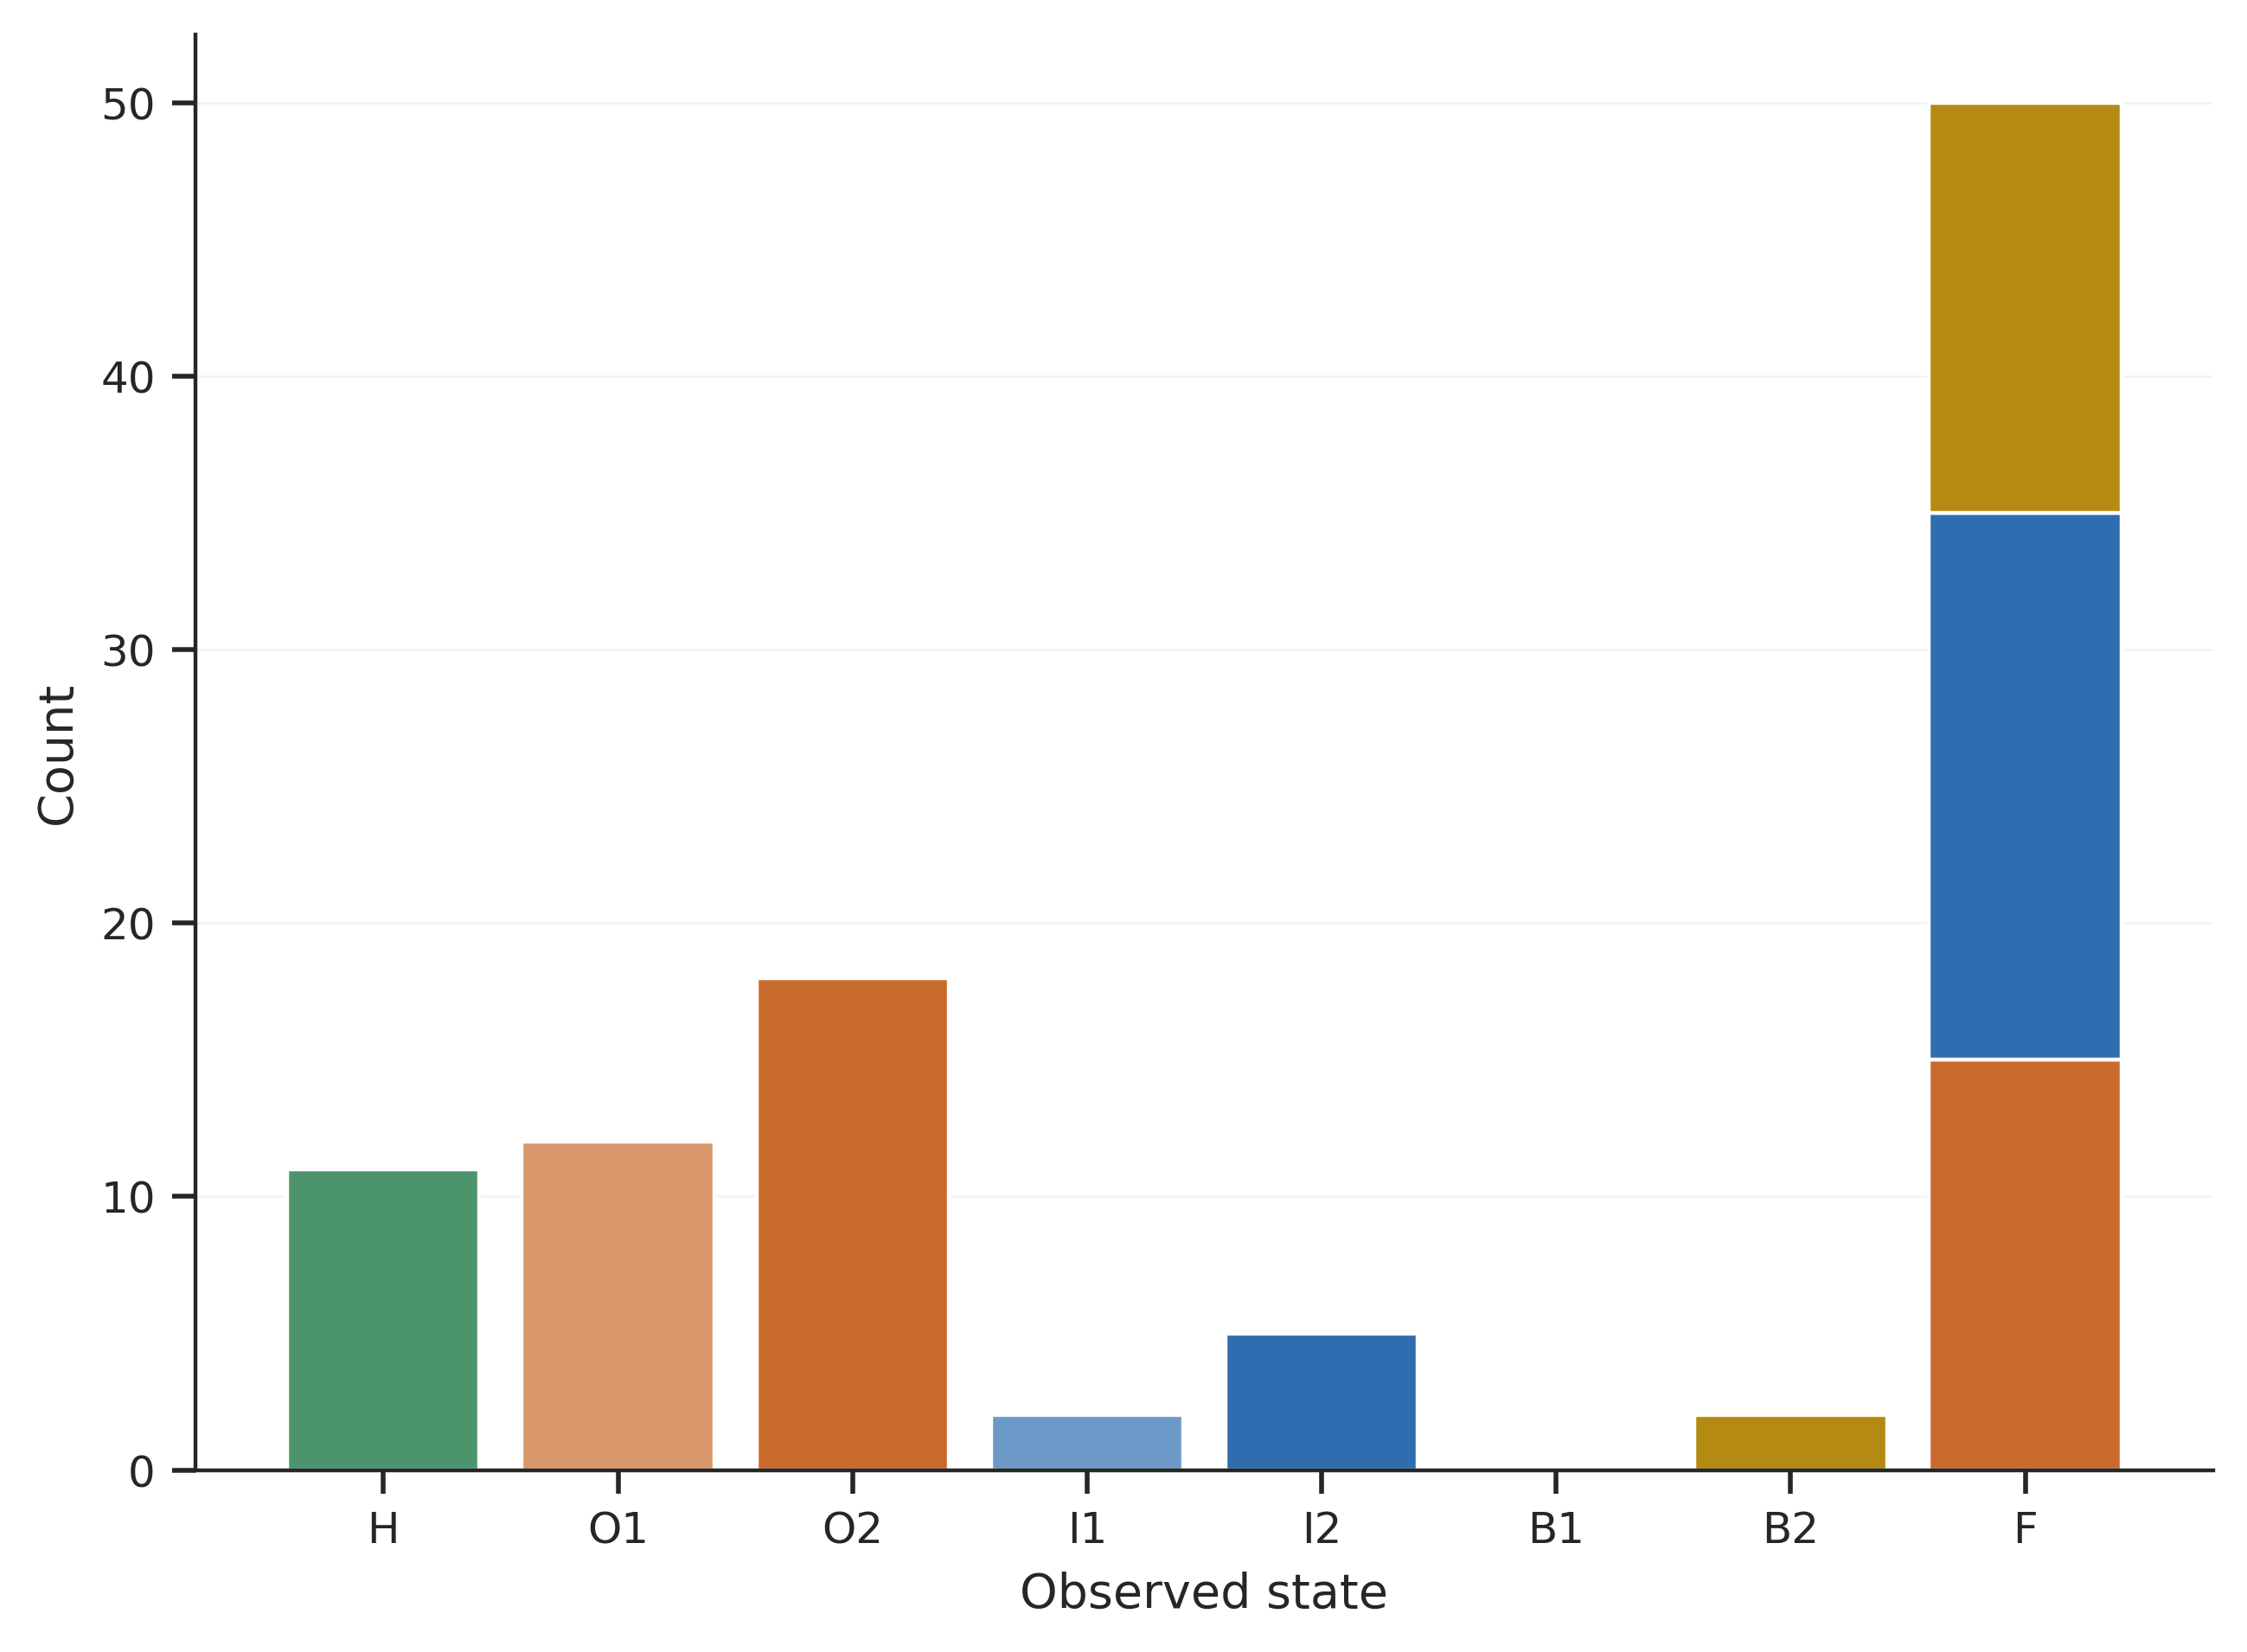

In [8]:
data = te.load_mode_augmented_censored_data(DATASET4)
failed_mode_time_counts, censored_state_time_counts = te.grouped_observation_counts(data)

observation_summary = pd.DataFrame([
    {"quantity": "bearings", "value": data["bearing_id"].nunique()},
    {"quantity": "failed", "value": int(data["is_failed"].sum())},
    {"quantity": "censored", "value": int((~data["is_failed"]).sum())},
    {"quantity": "censoring_time", "value": int(data.loc[~data["is_failed"], "observed_time"].mode().iloc[0])},
])
observation_summary.to_csv(TABLE_DIR / "right_censored_endpoint_observation_summary.csv", index=False)

display(observation_summary)
display(Markdown("### Failed bearings by fault mode and time"))
display(failed_mode_time_counts.to_frame())
display(Markdown("### Censored bearings by endpoint state and time"))
display(censored_state_time_counts.to_frame())

display(Markdown("### Dataset 4 observation view"))
if DATASET4_OBSERVATION_FIGURE.exists():
    display(Image(filename=str(DATASET4_OBSERVATION_FIGURE)))
else:
    display(Markdown(f"Dataset-4 observation figure not found at `{DATASET4_OBSERVATION_FIGURE}`."))


The transition-estimation sample contains 100 bearings: 50 failures and 50 right-censored endpoints at `t=20`. The failed rows are mode-labelled, while the censored rows retain observed transient endpoint states. The observation-view figure summarizes the same sample: the censored endpoints are concentrated in `H`, `O1`, and `O2`, while the failed bearings are stacked at `F` by fault mode. These two observation types identify the branch and severity dynamics used by the EM fit.


The EM algorithm is then fitted to the grouped failed and censored observations under the monotone transition structure.


In [9]:
fit = te.estimate_right_censored_endpoint_em(data, max_iter=MAX_ITER, tol=TOL)

fit_summary = pd.DataFrame([
    {"quantity": key, "value": value}
    for key, value in fit.metadata.items()
])
fit_summary.to_csv(TABLE_DIR / "right_censored_endpoint_fit_summary.csv", index=False)

display(fit_summary)
if fit.metadata["n_iterations"] != PAPER_REPORTED_ITERATIONS:
    display(Markdown(
        f"Note: the journal PDF text reports `{PAPER_REPORTED_ITERATIONS}` EM iterations, "
        f"but the current code and data converge in `{fit.metadata['n_iterations']}` iterations. "
        "Check the paper/version alignment before interpreting the mismatch."
    ))

,quantity,value
0,n_bearings,100
1,n_rows,100
2,n_failed,50
3,n_censored,50
4,termination_reason,converged
5,converged,True
6,n_iterations,908
7,final_log_likelihood,-341.736879
8,tol,0.000002
9,max_iter,2000


The estimator converges in 908 iterations with observed-data log-likelihood `-341.736879`. This matches the journal-version appendix, which reports the same convergence tolerance and iteration count.


The following cell reports the fitted transition matrix and expected state-level exit statistics corresponding to Table 1.


In [10]:
matrix = fit.transition_matrix.copy()
matrix_out = matrix.reset_index().rename(columns={"index": "from_state"})
matrix_out.to_csv(TABLE_DIR / "right_censored_endpoint_transition_matrix.csv", index=False)

display(Markdown("### Fitted transition matrix"))
display(matrix.style.format("{:.6f}"))

expected_summary = fit.expected_state_summary.reset_index().rename(columns={"index": "state"})
expected_summary.to_csv(TABLE_DIR / "right_censored_endpoint_expected_state_summary.csv", index=False)

display(Markdown("### Expected counts and exit probabilities"))
display(expected_summary.style.format({
    "expected_source_count": "{:.3f}",
    "expected_exit_count": "{:.3f}",
    "exit_probability": "{:.4f}",
}))

convergence_tail = fit.convergence_trace.tail(8).copy()
convergence_tail.to_csv(TABLE_DIR / "right_censored_endpoint_convergence_tail.csv", index=False)

display(Markdown("### Convergence tail"))
display(convergence_tail.style.format({
    "log_likelihood": "{:.9f}",
    "delta_log_likelihood": "{:.9e}",
    "max_parameter_change": "{:.9e}",
}))

### Fitted transition matrix

to_state,H,O1,O2,I1,I2,B1,B2,F
from_state,,,,,,,,
H,0.893945,0.053623,0.000000,0.032174,0.000000,0.020258,0.000000,0.000000
O1,0.000000,0.884144,0.115856,0.000000,0.000000,0.000000,0.000000,0.000000
O2,0.000000,0.000000,0.919438,0.000000,0.000000,0.000000,0.000000,0.080562
I1,0.000000,0.000000,0.000000,0.697911,0.302089,0.000000,0.000000,0.000000
I2,0.000000,0.000000,0.000000,0.000000,0.801585,0.000000,0.000000,0.198415
B1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000315,0.999685,0.000000
B2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.803195,0.196805
F,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000


### Expected counts and exit probabilities

,state,expected_source_count,expected_exit_count,exit_probability
0,H,839.191,89.000,0.1061
1,O1,284.837,33.000,0.1159
2,O2,186.193,15.000,0.0806
3,I1,82.757,25.000,0.3021
4,I2,100.799,20.000,0.1984
5,B1,17.005,17.000,0.9997
6,B2,76.218,15.000,0.1968
7,F,0.000,0.000,0.0000


### Convergence tail

,iteration,log_likelihood,delta_log_likelihood,max_parameter_change
900,901,-341.736880864,2.250544071e-07,2.087130782e-06
901,902,-341.736880641,2.236249657e-07,2.073933638e-06
902,903,-341.736880419,2.222044486e-07,2.060820586e-06
903,904,-341.736880198,2.207932539e-07,2.047791080e-06
904,905,-341.736879978,2.193908131e-07,2.034844582e-06
905,906,-341.736879760,2.179979788e-07,2.021980554e-06
906,907,-341.736879544,2.166133868e-07,2.009198464e-06
907,908,-341.736879329,2.152381171e-07,1.996497782e-06


The healthy state remains highly persistent, with an estimated one-step exit probability of `0.106`. Outer-race degradation progresses more slowly than the inner-race branch, while the `B1 -> B2` estimate is nearly one, indicating that the right-censored data provide little information about residence time in the early ball-defect state.


### 5.2 State-estimation performance

The following cell evaluates diagnostic-only labels, the unweighted Bayes posterior baseline from Eq. 3.2.4, and the tuned weighted posterior on held-out pre-failure observations.


In [11]:
transition_matrix_display = pd.read_csv(PAPER_TRANSITION_MATRIX).set_index("state")
display(transition_matrix_display.style.format("{:.4f}"))

predictions = se.generate_state_estimation_predictions(
    runs_input_path=RUNS_INPUT,
    confusion_matrix_path=CONFUSION_MATRIX,
    transition_matrix_path=PAPER_TRANSITION_MATRIX,
    seed=PREDICTION_SEED,
    alpha=ALPHA,
    beta=BETA,
    epsilon_g=EPSILON_G,
)

baseline_predictions = se.generate_unweighted_bayes_predictions(
    runs_input_path=RUNS_INPUT,
    confusion_matrix_path=CONFUSION_MATRIX,
    transition_matrix_path=PAPER_TRANSITION_MATRIX,
    seed=PREDICTION_SEED,
)

evaluation_rows, train_ids, evaluation_ids = se.held_out_operating_rows(
    predictions,
    train_fraction=TRAIN_FRACTION,
)
evaluation_rows = se.add_estimate_columns(evaluation_rows)

baseline_evaluation_rows, baseline_train_ids, baseline_evaluation_ids = se.held_out_operating_rows(
    baseline_predictions,
    train_fraction=TRAIN_FRACTION,
)
baseline_evaluation_rows = se.add_estimate_columns(baseline_evaluation_rows)

if train_ids != baseline_train_ids or evaluation_ids != baseline_evaluation_ids:
    raise ValueError("Baseline and tuned posterior evaluations use different bearing splits.")

comparison_columns = ["bearing_id", "t", "true_state", "predicted_state"]
if not evaluation_rows[comparison_columns].reset_index(drop=True).equals(
    baseline_evaluation_rows[comparison_columns].reset_index(drop=True)
):
    raise ValueError("Baseline and tuned posterior evaluations do not use the same diagnostic labels.")

weighted_metrics = se.state_estimation_metrics(evaluation_rows)
baseline_metrics = se.state_estimation_metrics(baseline_evaluation_rows)
recall_by_state = se.per_state_recall(evaluation_rows)

diagnostic_row = weighted_metrics.loc[
    weighted_metrics["estimator"].eq("Diagnostic-only label")
].copy()
baseline_row = baseline_metrics.loc[
    baseline_metrics["estimator"].eq("Belief-updated label")
].copy()
weighted_row = weighted_metrics.loc[
    weighted_metrics["estimator"].eq("Belief-updated label")
].copy()

baseline_row["estimator"] = "Unweighted Bayes posterior"
weighted_row["estimator"] = "Weighted posterior"

accuracy_metrics = pd.concat(
    [diagnostic_row, baseline_row, weighted_row],
    ignore_index=True,
)
accuracy_metrics.to_csv(TABLE_DIR / "state_estimation_metrics.csv", index=False)
recall_by_state.to_csv(TABLE_DIR / "per_state_recall.csv", index=False)

display(Markdown(
    f"Training bearings: `{len(train_ids)}`. Held-out bearings: `{len(evaluation_ids)}`. "
    f"Held-out operating observations: `{len(evaluation_rows):,}`."
))

accuracy_table = accuracy_metrics[[
    "estimator",
    "accuracy",
    "balanced_accuracy",
    "severity_1_exact_rate",
    "severity_2_exact_rate",
]]
display(accuracy_table.style.format({
    "accuracy": "{:.3f}",
    "balanced_accuracy": "{:.3f}",
    "severity_1_exact_rate": "{:.3f}",
    "severity_2_exact_rate": "{:.3f}",
}))

display(Markdown("### Per-state recall for the tuned weighted posterior"))
display(recall_by_state.style.format({
    "diagnostic_recall": "{:.3f}",
    "belief_updated_recall": "{:.3f}",
}))


,H,O_1,O_2,I_1,I_2,B_1,B_2,F
state,,,,,,,,
H,0.8900,0.0550,0.0000,0.0330,0.0000,0.0220,0.0000,0.0000
O_1,0.0000,0.8800,0.1200,0.0000,0.0000,0.0000,0.0000,0.0000
O_2,0.0000,0.0000,0.9200,0.0000,0.0000,0.0000,0.0000,0.0800
I_1,0.0000,0.0000,0.0000,0.7000,0.3000,0.0000,0.0000,0.0000
I_2,0.0000,0.0000,0.0000,0.0000,0.8000,0.0000,0.0000,0.2000
B_1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0003,0.9997,0.0000
B_2,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.8000,0.2000
F,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000


Training bearings: `700`. Held-out bearings: `300`. Held-out operating observations: `6,882`.

,estimator,accuracy,balanced_accuracy,severity_1_exact_rate,severity_2_exact_rate
0,Diagnostic-only label,0.628,0.725,0.416,0.300
1,Unweighted Bayes posterior,0.788,0.773,0.425,0.865
2,Weighted posterior,0.790,0.772,0.483,0.808


### Per-state recall for the tuned weighted posterior

,state,held_out_observations,diagnostic_recall,belief_updated_recall
0,H,2882,1.000,1.000
1,O1,1512,0.207,0.356
2,O2,1329,0.000,0.724
3,I1,436,0.954,0.956
4,I2,466,1.000,1.000
5,B1,138,1.000,0.370
6,B2,119,0.916,1.000


The held-out evaluation contains 300 bearings and 6,882 pre-failure observations. The diagnostic-only estimate obtains accuracy `0.628`. The unweighted Bayes posterior, which sets `alpha=beta=1` and uses no likelihood floor, increases accuracy to `0.788` and severity-2 exact accuracy to `0.865`. The tuned weighted posterior obtains the highest overall accuracy at `0.790`, but its severity-2 exact accuracy is lower at `0.808`, reflecting the effect of the stronger diagnostic exponent and likelihood floor.

The tuned posterior gain remains concentrated in advanced states, especially `O2` recall, which rises from `0.000` to `0.724`. The main adverse tradeoff is `B1` recall, which decreases from `1.000` to `0.370` because the fitted transition matrix moves probability quickly into `B2`.


The confusion matrices below show where the diagnostic-only baseline, the unweighted Bayes posterior, and the tuned weighted posterior assign probability mass across true states.


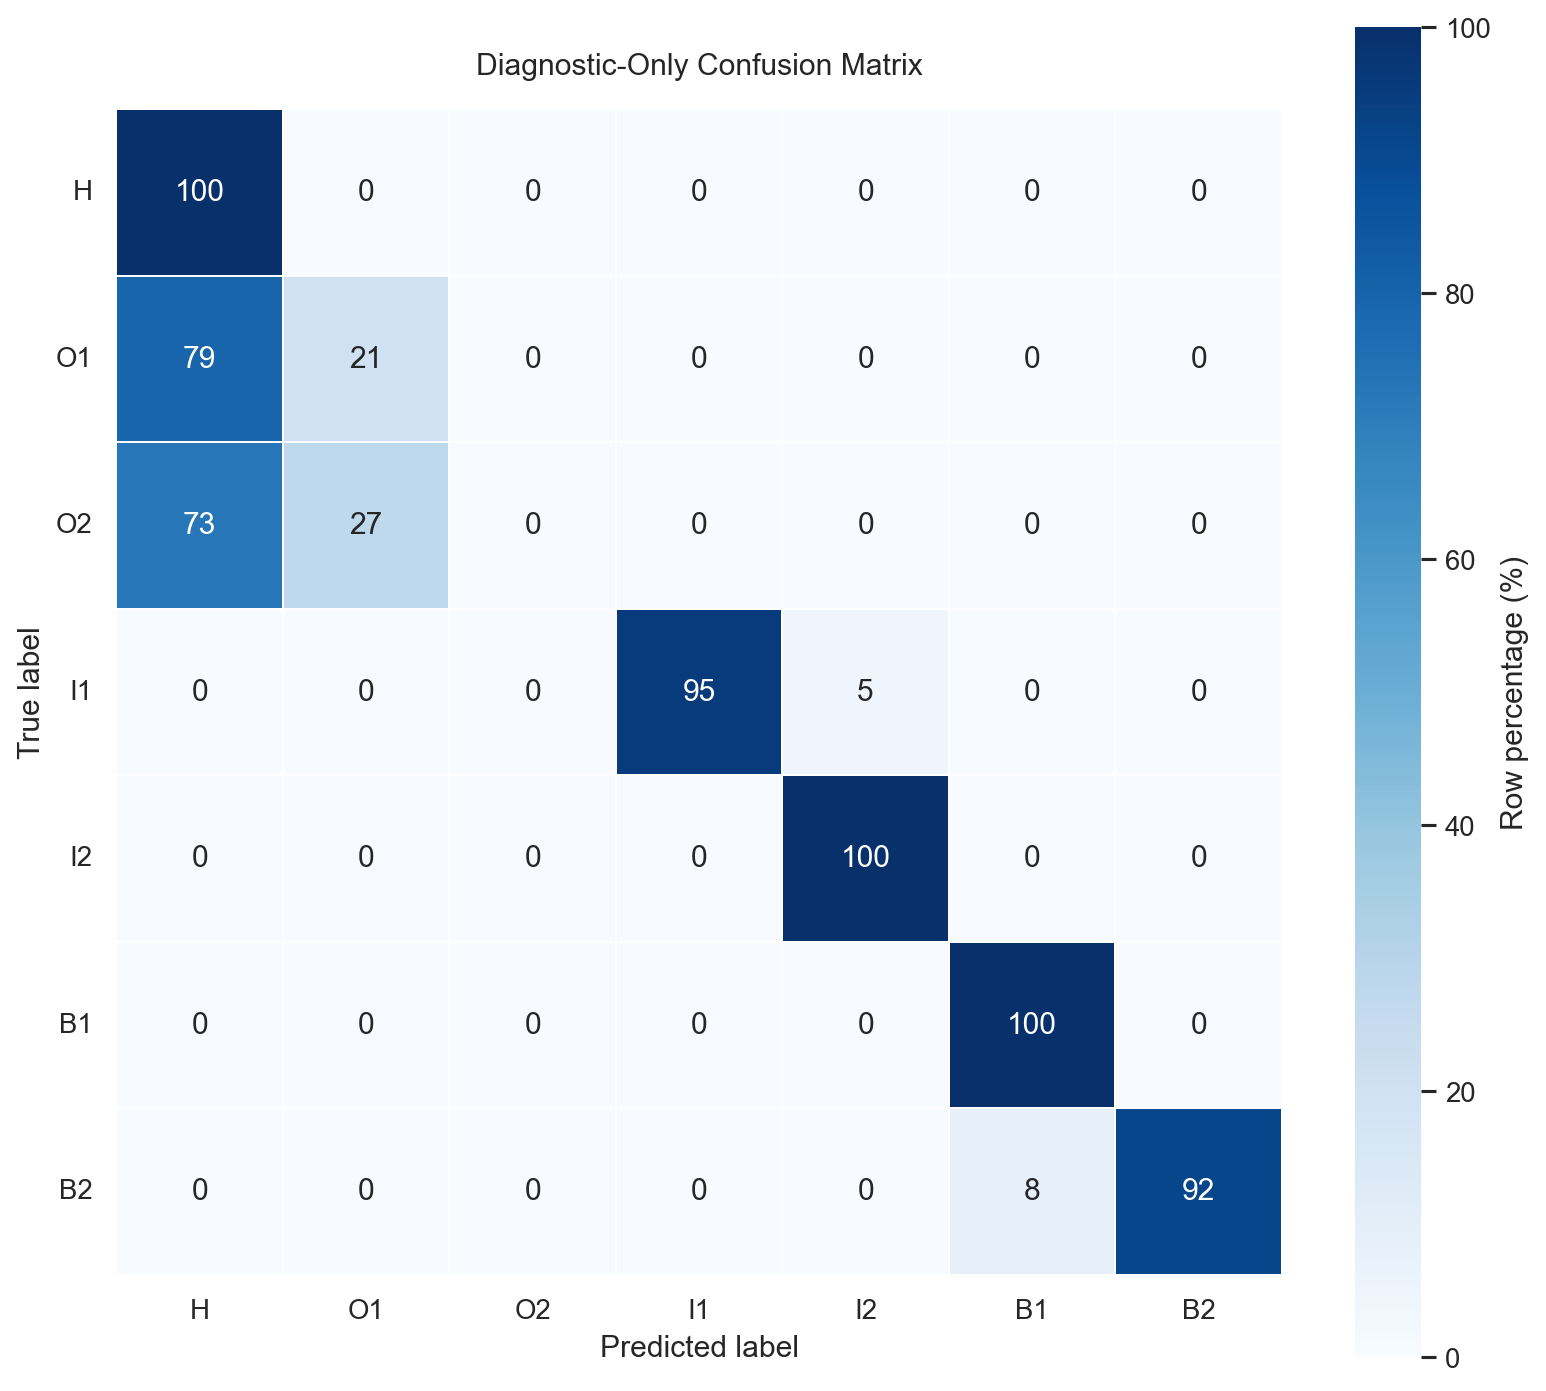

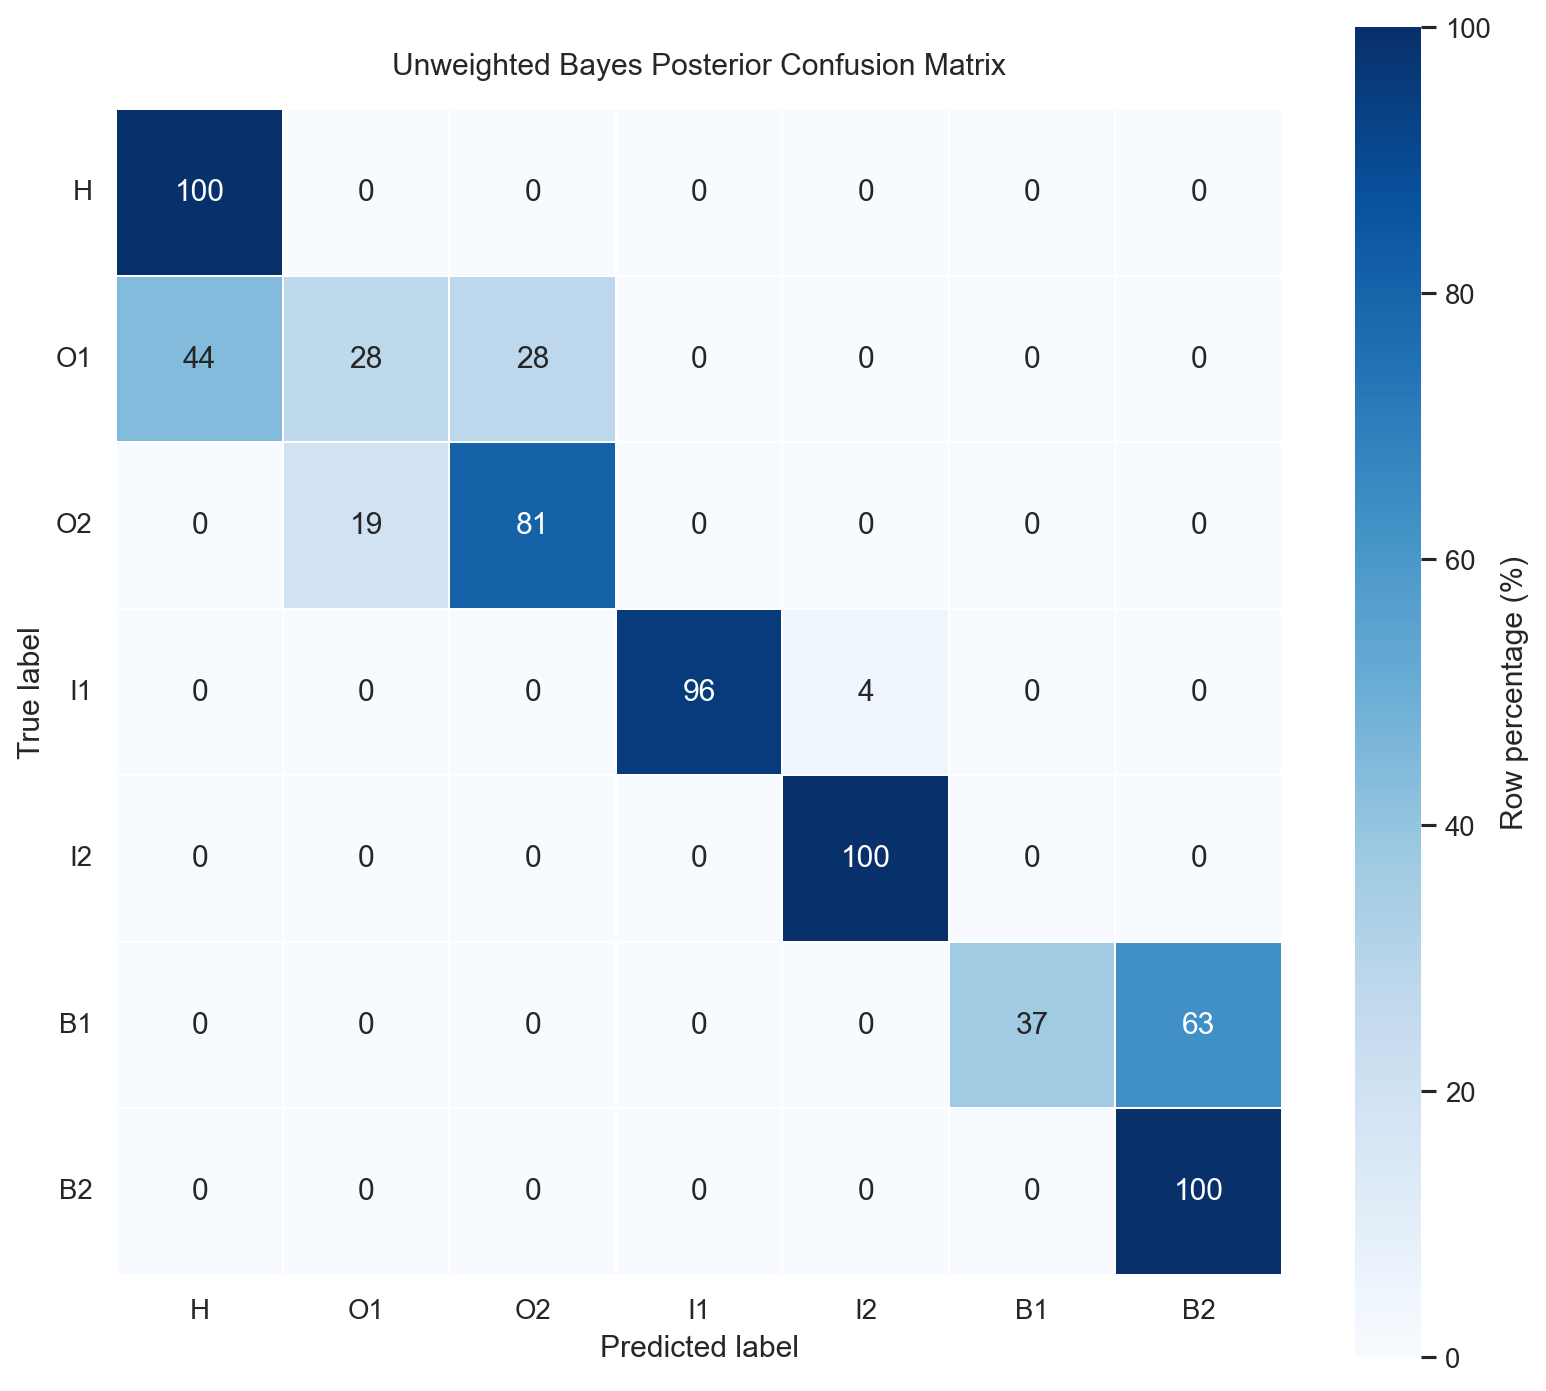

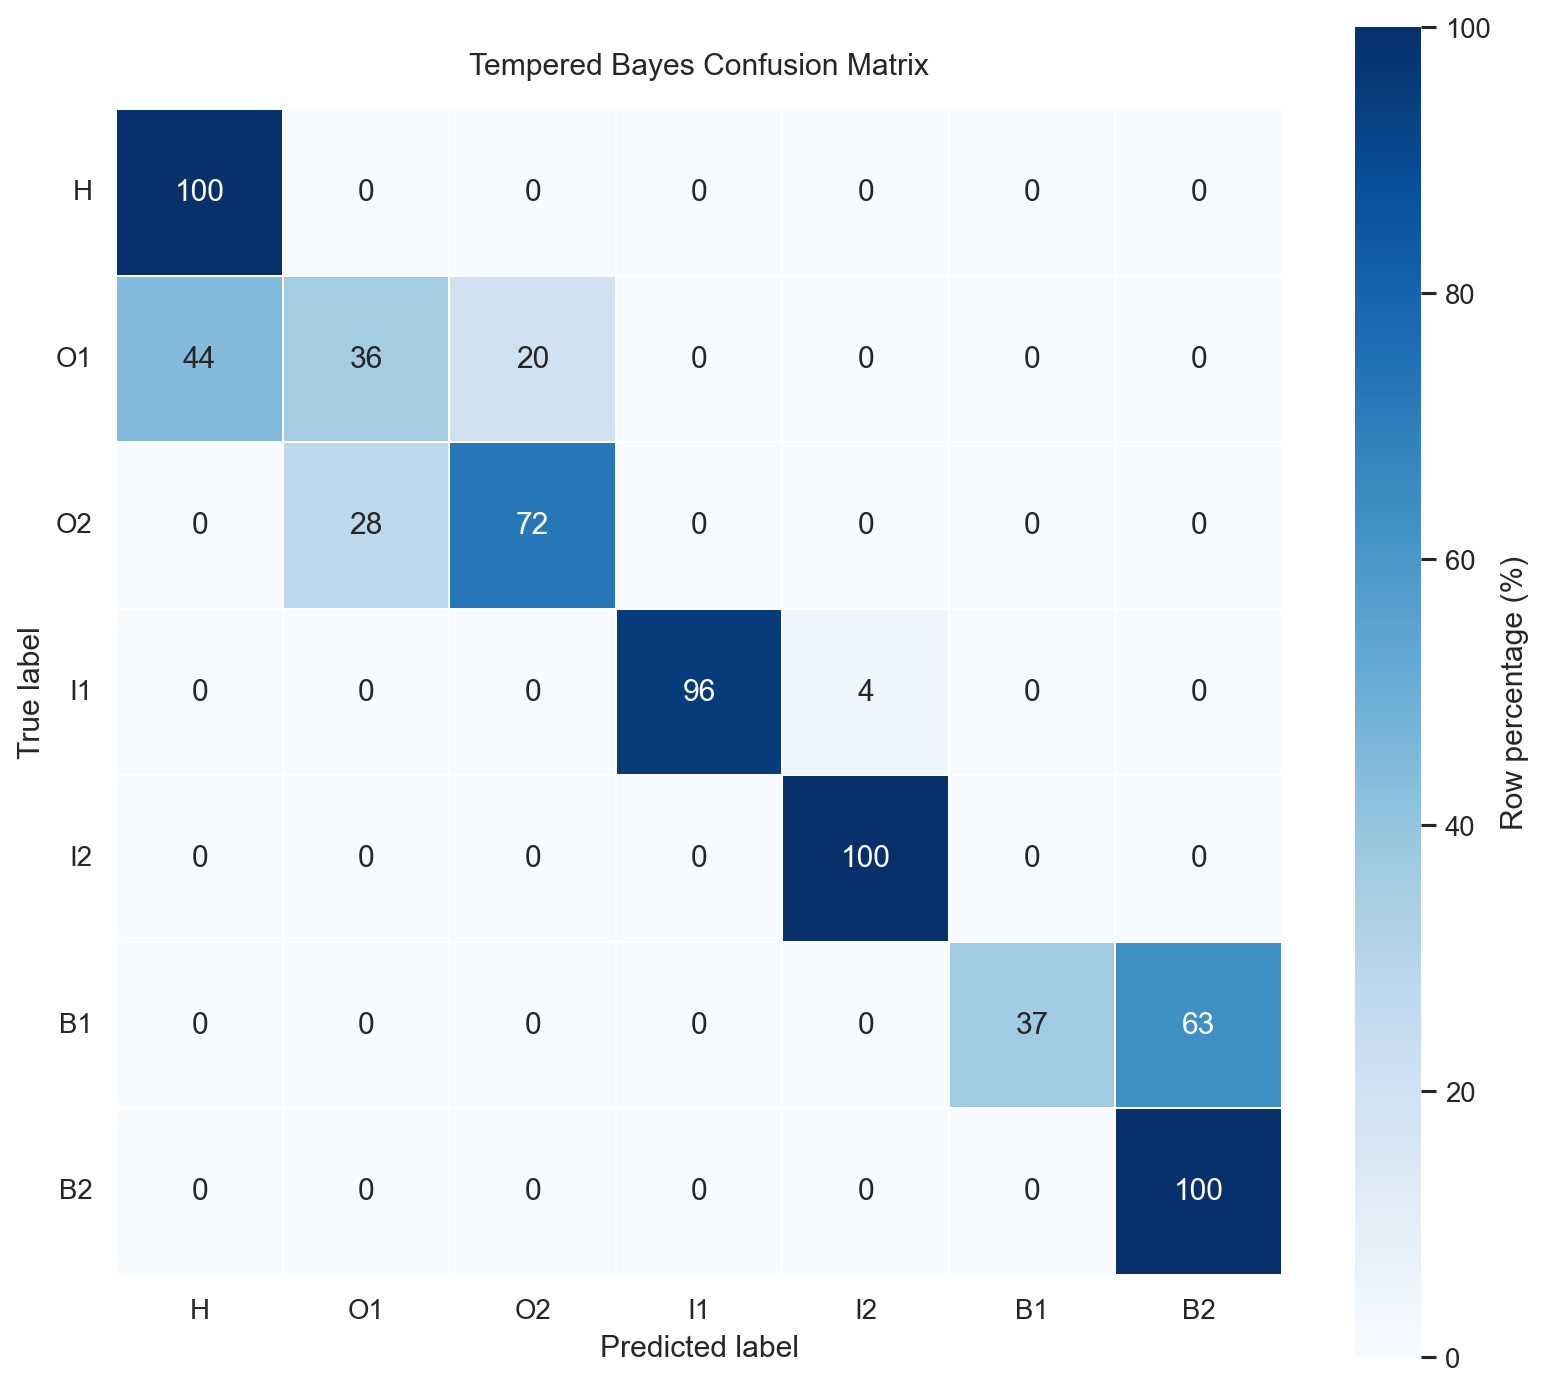

Saved confusion tables to `C:\Users\20202809\1MIAC15\0. Complete\paper_reproducible_results\results\tables` and figures to `C:\Users\20202809\1MIAC15\0. Complete\paper_reproducible_results\results\figures`.

In [12]:
diagnostic_counts = se.confusion_counts(evaluation_rows, "diagnostic_estimate")
baseline_bayes_counts = se.confusion_counts(baseline_evaluation_rows, "belief_estimate")
belief_counts = se.confusion_counts(evaluation_rows, "belief_estimate")
diagnostic_percent = se.row_percentages(diagnostic_counts)
baseline_bayes_percent = se.row_percentages(baseline_bayes_counts)
belief_percent = se.row_percentages(belief_counts)

diagnostic_counts.to_csv(TABLE_DIR / "diagnostic_confusion_counts.csv")
baseline_bayes_counts.to_csv(TABLE_DIR / "baseline_bayes_confusion_counts.csv")
belief_counts.to_csv(TABLE_DIR / "belief_confusion_counts.csv")
diagnostic_percent.to_csv(TABLE_DIR / "diagnostic_confusion_percent.csv")
baseline_bayes_percent.to_csv(TABLE_DIR / "baseline_bayes_confusion_percent.csv")
belief_percent.to_csv(TABLE_DIR / "belief_confusion_percent.csv")

def plot_confusion(percentages, title, output_path):
    labels = percentages.round(0).astype(int).astype(str)
    fig, ax = plt.subplots(figsize=(9, 8), dpi=180)
    sns.heatmap(
        percentages,
        ax=ax,
        cmap="Blues",
        vmin=0,
        vmax=100,
        annot=labels,
        fmt="",
        square=True,
        linewidths=0.8,
        linecolor="white",
        cbar_kws={"label": "Row percentage (%)"},
    )
    ax.set_title(title, pad=14)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticklabels(percentages.columns, rotation=0)
    ax.set_yticklabels(percentages.index, rotation=0)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

plot_confusion(
    diagnostic_percent,
    "Diagnostic-Only Confusion Matrix",
    FIGURE_DIR / "diagnostic_confusion_percent.png",
)
plot_confusion(
    baseline_bayes_percent,
    "Unweighted Bayes Posterior Confusion Matrix",
    FIGURE_DIR / "baseline_bayes_confusion_percent.png",
)
plot_confusion(
    belief_percent,
    "Tempered Bayes Confusion Matrix",
    FIGURE_DIR / "belief_confusion_percent.png",
)

display(Markdown(f"Saved confusion tables to `{TABLE_DIR}` and figures to `{FIGURE_DIR}`."))

The diagnostic matrix shows that `O1` and `O2` are frequently assigned to `H` and that `O2` is never exactly recovered. The unweighted Bayes posterior already recovers advanced degradation states much better than the diagnostic-only label, but it also moves observations out of `B1` aggressively. The tuned weighted posterior gives a small overall accuracy gain relative to the unweighted baseline, although the baseline remains stronger on severity-2 exact classification.


### 5.3 Maintenance-cost performance

The following cell tunes and evaluates the diagnostic-evidence policy (`CBR0`), an unweighted Bayes posterior threshold policy (`CBR1-Bayes`), and the tuned weighted posterior policy (`CBR1`) on the split described in the paper.


In [13]:
policy_summary = mc.policy_summary(
    predictions,
    CONFUSION_MATRIX,
    train_fraction=TRAIN_FRACTION,
    alpha=ALPHA,
    beta=BETA,
    costs=COSTS,
    baseline_predictions=baseline_predictions,
)
policy_summary.to_csv(TABLE_DIR / "maintenance_policy_summary.csv", index=False)

def parse_policy_parameters(parameter_string):
    return dict(part.split("=", maxsplit=1) for part in parameter_string.split("; "))

selected_policy_parameters = pd.DataFrame([
    {
        "policy": row.policy,
        **{
            key: value
            for key, value in parse_policy_parameters(row.parameters).items()
            if key in {"alpha", "beta", "eta_O", "eta_I", "eta_B"}
        },
    }
    for row in policy_summary.itertuples(index=False)
]).fillna("")

maintenance_table = (
    policy_summary.rename(columns={
        "ECC": "cost_per_bearing",
        "ECL": "cycle_length",
        "preventive_replacements": "preventive",
        "corrective_replacements": "corrective",
    })
    [["policy", "cost_rate", "cost_per_bearing", "cycle_length", "preventive", "corrective"]]
)

display(Markdown("### Selected policy parameters"))
display(selected_policy_parameters)
display(Markdown("### Held-out maintenance performance"))
display(maintenance_table.style.format({
    "cost_rate": "{:.3f}",
    "cost_per_bearing": "{:.3f}",
    "cycle_length": "{:.3f}",
}))

### Selected policy parameters

,policy,eta_O,eta_I,eta_B,alpha,beta
0,CBR0,0.5,0.9,0.9,,
1,CBR1-Bayes,0.4,0.8,0.9,1,1
2,CBR1,0.4,0.9,0.9,1,1.8


### Held-out maintenance performance

,policy,cost_rate,cost_per_bearing,cycle_length,preventive,corrective
0,CBR0,0.730,10.000,13.700,300,0
1,CBR1-Bayes,0.721,10.533,14.607,296,4
2,CBR1,0.682,10.400,15.257,297,3


CBR0 obtains a held-out cost rate of `0.730` with 300 preventive and no corrective replacements. The unweighted Bayes posterior policy (`CBR1-Bayes`) uses the same threshold grid and cost model as CBR1, but computes the posterior with `alpha=beta=1` and no likelihood floor; it obtains a cost rate of `0.721`, corresponding to a `1.2%` reduction relative to CBR0, with four corrective replacements. The tuned weighted posterior policy (`CBR1`) obtains the lowest cost rate, `0.682`, a `6.6%` reduction relative to CBR0 and a `5.5%` reduction relative to `CBR1-Bayes`, by increasing average cycle length to `15.257` time steps while producing three corrective replacements.


## Appendix C Uncertainty and Sensitivity Analysis

The following cells reproduce the uncertainty and sensitivity checks reported in Appendix C. These calculations are cached because the trajectory bootstrap and sensitivity reruns are slower than the main result tables.


In [14]:
appendix_c_result = ac.cached_appendix_c(
    runs_input_path=RUNS_INPUT,
    confusion_matrix_path=CONFUSION_MATRIX,
    transition_matrix_path=PAPER_TRANSITION_MATRIX,
    output_dir=TABLE_DIR,
    prediction_seed=PREDICTION_SEED,
    train_fraction=TRAIN_FRACTION,
    alpha=ALPHA,
    beta=BETA,
    epsilon_g=EPSILON_G,
    costs=COSTS,
    predictions=predictions,
    evaluation_rows=evaluation_rows,
    policy_summary=policy_summary,
)

appendix_cache_status = "loaded from cache" if appendix_c_result.cache_hit else "computed and cached"
display(Markdown(f"Appendix C outputs were `{appendix_cache_status}`."))

appendix_table_4 = appendix_c_result.heldout_differences.copy()
appendix_table_4["95% CI"] = appendix_table_4.apply(
    lambda row: f"[{row['ci_2_5']:.3f}, {row['ci_97_5']:.3f}]",
    axis=1,
)
appendix_table_4 = appendix_table_4.rename(columns={
    "metric": "metric",
    "point_estimate": "difference",
})[["metric", "difference", "95% CI"]]

display(Markdown("### Table 4: Trajectory-level bootstrap differences"))
display(appendix_table_4.style.format({"difference": "{:.3f}"}))

appendix_table_5 = appendix_c_result.confusion_uncertainty.copy()
appendix_table_5["95% CI"] = appendix_table_5.apply(
    lambda row: f"[{row['ci_2_5']:.3f}, {row['ci_97_5']:.3f}]",
    axis=1,
)
appendix_table_5 = appendix_table_5.rename(columns={"class": "class", "recall": "recall"})[
    ["class", "recall", "95% CI"]
]

display(Markdown("### Table 5: Class-wise CNN recall uncertainty"))
display(appendix_table_5.style.format({"recall": "{:.3f}"}))

appendix_table_6 = appendix_c_result.state_sensitivity.copy().rename(columns={
    "sensitivity": "sensitivity",
    "setting": "setting",
    "balanced_accuracy": "balanced_accuracy",
    "severity_2_exact_accuracy": "severity_2_accuracy",
})

display(Markdown("### Table 6: State-estimation sensitivity checks"))
display(appendix_table_6.style.format({
    "accuracy": "{:.3f}",
    "balanced_accuracy": "{:.3f}",
    "severity_2_accuracy": "{:.3f}",
}))

appendix_table_7 = appendix_c_result.cost_sensitivity.copy().rename(columns={
    "C_C_over_C_P": "C_C / C_P",
    "policy": "policy",
    "cost_rate": "cost_rate",
    "corrective_replacements": "corrective",
})

display(Markdown("### Table 7: Cost-ratio sensitivity checks"))
display(appendix_table_7.style.format({"C_C / C_P": "{:.0f}", "cost_rate": "{:.3f}"}))

Appendix C outputs were `loaded from cache`.

### Table 4: Trajectory-level bootstrap differences

,metric,difference,95% CI
0,accuracy,0.162,"[0.132, 0.193]"
1,balanced_accuracy,0.047,"[0.030, 0.067]"
2,severity_2_exact_accuracy,0.508,"[0.440, 0.571]"
3,cost_rate,-0.048,"[-0.079, -0.014]"
4,cycle_length,1.557,"[1.267, 1.867]"
5,corrective_replacements,3.000,"[0.000, 7.000]"


### Table 5: Class-wise CNN recall uncertainty

,class,recall,95% CI
0,H,1.000,"[0.796, 1.000]"
1,O1,0.200,"[0.070, 0.452]"
2,O2,0.000,"[0.000, 0.204]"
3,I1,0.933,"[0.702, 0.988]"
4,I2,1.000,"[0.796, 1.000]"
5,B1,1.000,"[0.796, 1.000]"
6,B2,0.933,"[0.702, 0.988]"


### Table 6: State-estimation sensitivity checks

,sensitivity,setting,accuracy,balanced_accuracy,severity_2_accuracy
0,likelihood_floor,epsilon_G=1e-06,0.790,0.772,0.808
1,likelihood_floor,epsilon_G=1e-05,0.790,0.772,0.808
2,likelihood_floor,epsilon_G=0.0001,0.790,0.772,0.808
3,likelihood_floor,epsilon_G=0.001,0.790,0.772,0.807
4,fusion_exponents,alpha=0.8; beta=1.8,0.770,0.761,0.857
5,fusion_exponents,alpha=1; beta=1.6,0.791,0.773,0.822
6,fusion_exponents,alpha=1; beta=1.8,0.790,0.772,0.808
7,fusion_exponents,alpha=1; beta=2,0.793,0.774,0.805
8,fusion_exponents,alpha=1.2; beta=1.8,0.780,0.763,0.685


### Table 7: Cost-ratio sensitivity checks

,C_C / C_P,policy,cost_rate,corrective
0,2,Diagnostic-evidence,0.730,0
1,2,Corrected-belief,0.662,3
2,5,Diagnostic-evidence,0.730,0
3,5,Corrected-belief,0.682,3
4,10,Diagnostic-evidence,0.730,0
5,10,Corrected-belief,0.714,3


The bootstrap intervals support the main state-estimation result: the corrected-belief estimate improves accuracy, balanced accuracy, and severity-2 exact accuracy relative to the diagnostic baseline. The maintenance bootstrap shows a lower cost rate and longer cycle length for CBR1, but also confirms that the improvement is accompanied by corrective replacements.

The diagnostic recall intervals are wide because each class has 15 CNN test samples. The sensitivity checks show that the main state-estimation result is insensitive to the tested likelihood-floor values and reasonably stable around the selected exponent pair; the cost-ratio check shows that the corrected-belief policy remains lower-cost for the tested fixed-decision ratios, although the advantage narrows as corrective replacement becomes more expensive.
